## Ejercicio 3  

**Iris** es el género de una planta herbácea con flores que se utilizan en decoración.  
Dentro de este género existen diversas especies, entre las que se han estudiado:  

- *Iris setosa*  
- *Iris versicolor*  
- *Iris virginica*  

(ver Figura 2).  

Estas tres especies pueden distinguirse según las **dimensiones de sus pétalos y sépalos**.  
Un grupo de investigadores recopiló información de las **longitudes y anchos** de los pétalos y sépalos de **50 plantas de cada especie**.  

- En el archivo `iris81_trn.csv` se encuentra el conjunto de **entrenamiento**.  
- En el archivo `iris81_tst.csv` se encuentra el conjunto de **prueba**, generado a partir de estas mediciones (en cm).  

Cada muestra está acompañada de un **código binario** que indica la clase (especie) recon


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
estructura = np.array([4, 2, 3])
cant_capas = len(estructura) - 1
cant_salidas = estructura[-1]

In [3]:
def load_data(path): 
  
  data = np.loadtxt(path, delimiter=",")
  cant_entradas = estructura[0]

  X = data[:, :cant_entradas]
  y = data[:, cant_entradas:]

  X = np.hstack(( -np.ones((X.shape[0], 1)), X ))

  return X, y

In [4]:
X_train, Y_train = load_data("./data/iris81_trn.csv")
# print(X_train)

In [32]:
def init_weights(): 
  w = []

  for i in range(cant_capas): 
    n_neuronas = estructura[i+1]
    n_entradas = estructura[i] + 1 # Sumo uno por el bias
    w_aux = np.random.rand( n_neuronas, n_entradas)-0.5
    w.append(w_aux)

  return w
w = init_weights()

In [6]:
def sigmoidea(v):
    return ((2/(1+np.exp(-v)))-1)

def d_sigmoidea(y):
    return ((1+y)*(1-y))

y = np.empty(cant_capas, dtype=object)
delta = np.empty(cant_capas, dtype=object)

In [7]:
def forward_prop(entradas):
  #entradas = X_train[patron]
  for capa in range(cant_capas): 
      # Salida lineal
      z = np.dot(w[capa], entradas)
      # Salida no lineal
      y[capa] = sigmoidea(z)
      entradas = np.hstack(([-1], y[capa]))
  return y

In [8]:
def back_prop(y_deseada, y): 
  e = y_deseada - y[-1]
  delta[-1] = e * 1/2 * d_sigmoidea(y[-1])

  for i in range(cant_capas - 1, 0, -1): 
    w_i = w[i][:, 1:].T # Elimino la col del bias
    d = np.dot(w_i, delta[i])
    delta[i-1] = d*(1/2)*d_sigmoidea(y[i-1])

  return delta

In [9]:
def actualizacion(patron, delta, tasa): 
  entradas = X_train[patron]
  for capa in range(cant_capas): 
    delta_peso = tasa * np.outer(delta[capa], entradas)
    w[capa] += delta_peso

    entradas = np.hstack(([-1], y[capa]))

  return w

In [ ]:
# Hiperparámetros
epocas = 2000
tasa_aprendizaje = 0.1
perc_error_max = 0.01  # Tolerancia máxima de error (10%)

# Métricas por época
errores_por_epoca = []
mse_por_epoca = []

# Entrenamiento
for epoca in range(epocas): 
    # Fase de entrenamiento (forward + backprop + actualización)
    for patron in range(len(X_train)):
        y_d = Y_train[patron]
        y = forward_prop(X_train[patron])                     # Propagación hacia adelante
        delta = back_prop(y_d, y)                    # Retropropagación del error
        w = actualizacion(patron, delta, tasa_aprendizaje)  # Actualización de pesos
        # print(w)
    # Evaluación del desempeño
    errores = 0     # Cantidad de predicciones incorrectas
    cont_mse = 0.0  # Error cuadratico medio sobre todos los patrones  

    for patron in range(len(X_train)):
        
        y = forward_prop(X_train[patron])
        # Winner takes all
        yc = np.full(3, -1)   # vector de elementos en -1
        # Elegimos y[1] ya que y[0] tiene la salida de la capa oculta
        index = np.argmax(y[1])
        yc[index] = 1

        if (Y_train[patron] != yc).any(): 
            errores += 1
        
        cont_mse += np.sum(np.square(Y_train[patron] - y[-1]))

    # Guardar métricas
    # Calculamos el error cuadratico medio promedio
    mse = cont_mse / len(X_train)
    mse_por_epoca.append(mse)

    perc_error = errores / len(X_train)
    errores_por_epoca.append(perc_error)

    # Porcentaje de acierto obtenido
    acierto = 100 * (1 - perc_error)

    

    # Criterio de parada por convergencia
    if perc_error < perc_error_max: 
        # Imprimir resultados
        print("🟢 Finalizado por convergencia (error < perc_error_max)")
        print(f"Época {epoca+1}/{epocas} → Errores: {errores}/{len(X_train)} | Acierto: {acierto:.2f}% | MSE: {mse:.6f}")

        break
else:
    print("🔁 Finalizado por límite de épocas")
    print(f"Época {epoca+1}/{epocas} → Errores: {errores}/{len(X_train)} | Acierto: {acierto:.2f}% | MSE: {mse:.6f}")


🟢 Finalizado por convergencia (error < perc_error_max)
Época 85/2000 → Errores: 1/111 | Acierto: 99.10% | MSE: 1.060592


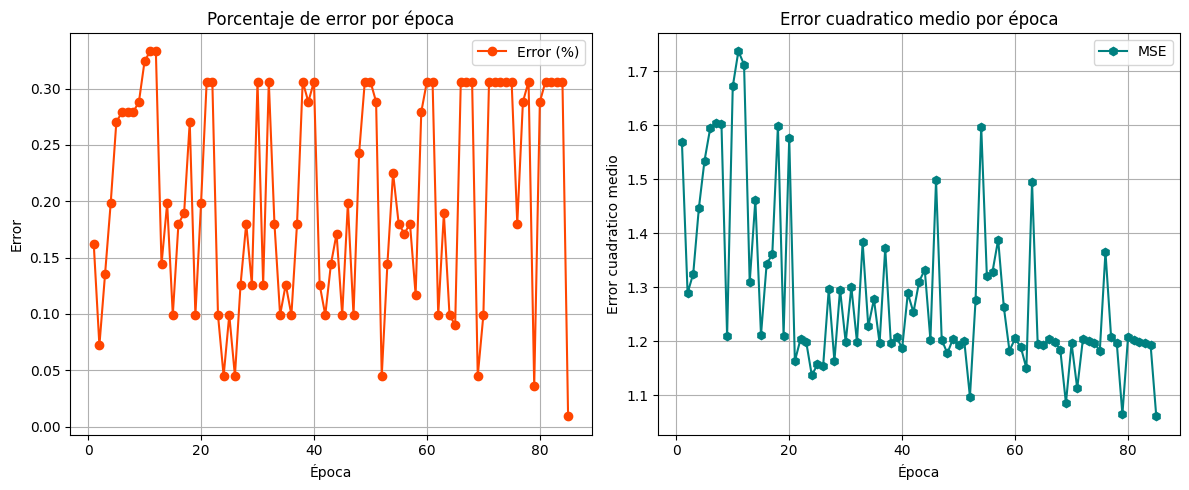

In [34]:
epocas = range(1, len(errores_por_epoca) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de errores
ax[0].plot(epocas, errores_por_epoca, marker='o', color='orangered', label='Error (%)')
ax[0].set_title('Porcentaje de error por época')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Error')
ax[0].grid(True)
ax[0].legend()

# Gráfico de MSE
ax[1].plot(epocas, mse_por_epoca, marker='h', color='teal', label='MSE')
ax[1].set_title('Error cuadratico medio por época')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Error cuadratico medio')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

In [35]:
X_tst, Y_tst = load_data("./data/iris81_tst.csv")

errores = 0

salidas_capa_oculta = []
y_saved = []

for patron in range (len(X_tst)): 
  y = forward_prop(X_tst[patron])
  
  # The winner takes all
  yc = np.full(3, -1)
  index = np.argmax(y[1])
  yc[index] = 1
  
  if((Y_tst[patron] != yc).any()): errores += 1

  salidas_capa_oculta.append(np.sign(y[0]))
  y_saved.append(yc)


acierto = (1-errores/len(X_tst))*100
print("El Test finalizo con: ", errores, "/", len(X_tst), " errores ")
print("Tasa de acierto: ", round(acierto,2),'%')

El Test finalizo con:  0 / 37  errores 
Tasa de acierto:  100.0 %
